In [1]:
from google.colab import files

uploaded = files.upload()

Saving patients.xml to patients.xml


In [2]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.pyplot as plt

In [3]:
# Parse the XML file
tree = ET.parse("patients.xml")
root = tree.getroot()

In [4]:
patients = root.findall("./patients/patient")

ages = []

for patient in patients:
    age_text = patient.get("age")

    if age_text is not None:
        ages.append(float(age_text))

print("Number of patients:", len(patients))
print("Number of ages extracted:", len(ages))
print("First 10 ages:", ages[:10])
print("Minimum age:", min(ages))
print("Maximum age:", max(ages))

Number of patients: 324357
Number of ages extracted: 324357
First 10 ages: [19.529988374393394, 1.6021974892211832, 19.317022680802072, 79.44120768829171, 71.20386333449743, 77.30270711879035, 4.246844166003803, 24.334513846211735, 26.513040128614485, 32.32621986433787]
Minimum age: 0.00010629282758800596
Maximum age: 84.99855742449432


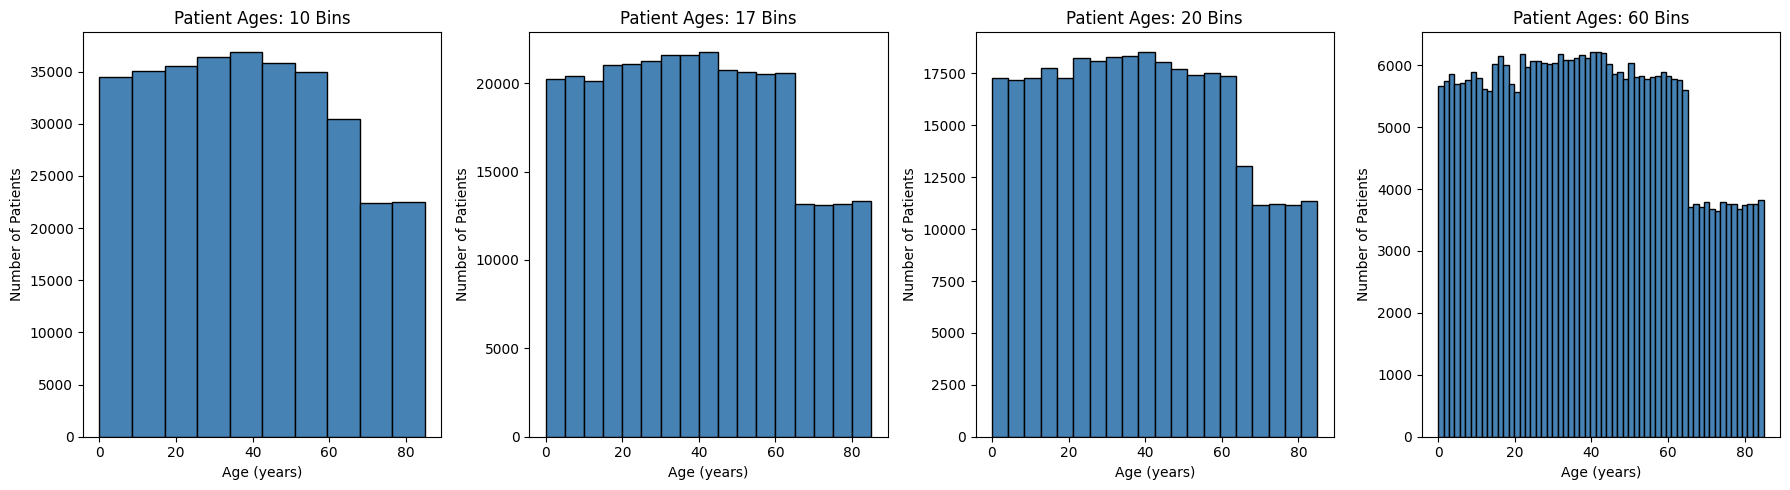

In [5]:
# histogram
bin_choices = [10, 17, 20, 60]

fig, axes = plt.subplots(1, len(bin_choices), figsize=(18, 5))

for ax, number_of_bins in zip(axes, bin_choices):
    ax.hist(
        ages,
        bins=number_of_bins,
        edgecolor="black",
        color="steelblue"
    )

    ax.set_title(f"Patient Ages: {number_of_bins} Bins")
    ax.set_xlabel("Age (years)")
    ax.set_ylabel("Number of Patients")

plt.tight_layout()
plt.show()

In [6]:
# duplicate analysis

age_counts = Counter(ages)

duplicate_ages = {
    age: count
    for age, count in age_counts.items()
    if count > 1
}

print("Total number of patients:", len(ages))
print("Number of unique age values:", len(age_counts))
print("Number of duplicated age values:", len(duplicate_ages))

if duplicate_ages:
    print("\nThe following exact ages occurred more than once:")

    for age, count in sorted(duplicate_ages.items()):
        print(f"Age {age}: {count} patients")
else:
    print("\nNo patients share the exact same age.")

Total number of patients: 324357
Number of unique age values: 324357
Number of duplicated age values: 0

No patients share the exact same age.


In [7]:
# find genders

genders = []

for patient in patients:
    gender = patient.get("gender")

    if gender is not None:
        genders.append(gender)

print("First 10 gender values:", genders[:10])


# different gender count
gender_counts = Counter(genders)

print("Distinct gender categories:", sorted(gender_counts.keys()))
print("Gender counts:")

for gender, count in gender_counts.items():
    print(f"{gender}: {count}")

First 10 gender values: ['female', 'female', 'male', 'male', 'male', 'female', 'female', 'female', 'female', 'male']
Distinct gender categories: ['female', 'male', 'unknown']
Gender counts:
female: 165293
male: 158992
unknown: 72


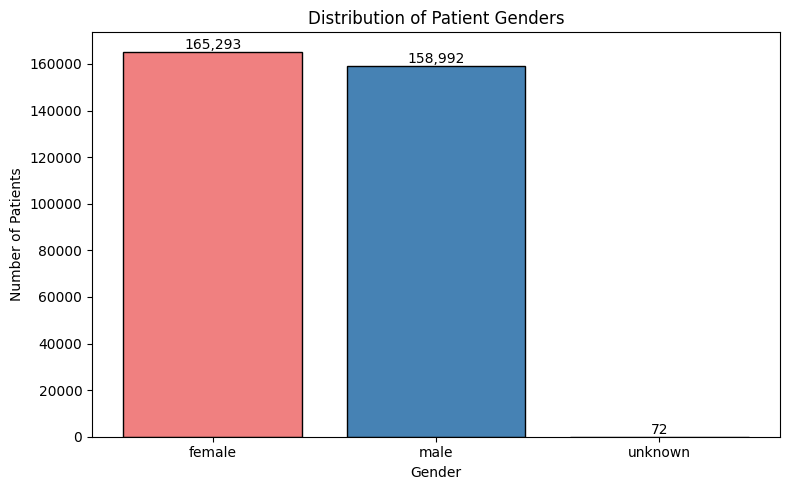

In [8]:
# plot gender distribution
categories = list(gender_counts.keys())
counts = list(gender_counts.values())

plt.figure(figsize=(8, 5))

bars = plt.bar(
    categories,
    counts,
    color=["lightcoral", "steelblue", "gray"],
    edgecolor="black"
)

plt.title("Distribution of Patient Genders")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("gender_distribution.png", dpi=300)
plt.show()

In [10]:
# Create patient records
patient_records = []

for patient in patients:
    record = {
        "name": patient.get("name"),
        "age": float(patient.get("age")),
        "gender": patient.get("gender")
    }

    patient_records.append(record)

# sorted
sorted_patients = sorted(
    patient_records,
    key=lambda patient: patient["age"],
    reverse=True
)

oldest_patient = sorted_patients[0]

print("\nOldest patient:")
print("Name:", oldest_patient["name"])
print("Age:", oldest_patient["age"])
print("Gender:", oldest_patient["gender"])


# Retrieve the top 10 oldest patients
k = 10
top_k_oldest = sorted_patients[:k]

print(f"\nTop {k} oldest patients:")

for rank, patient in enumerate(top_k_oldest, start=1):
    print(
        f"{rank}. {patient['name']}, "
        f"age={patient['age']:.4f}, "
        f"gender={patient['gender']}"
    )


Oldest patient:
Name: Monica Caponera
Age: 84.99855742449432
Gender: female

Top 10 oldest patients:
1. Monica Caponera, age=84.9986, gender=female
2. Raymond Leigh, age=84.9983, gender=male
3. Tracy Walker, age=84.9982, gender=female
4. Michael Ali, age=84.9979, gender=male
5. Stephan Yeargin, age=84.9972, gender=male
6. Caprice Medina, age=84.9965, gender=female
7. Michael Bowden, age=84.9964, gender=male
8. Helen Guest, age=84.9962, gender=female
9. Elizabeth Jackson, age=84.9962, gender=female
10. Agnes Weaver, age=84.9958, gender=female


In [11]:
def find_two_oldest(patient_records):
    oldest = None
    second_oldest = None

    for patient in patient_records:
        if oldest is None or patient["age"] > oldest["age"]:
            second_oldest = oldest
            oldest = patient

        elif second_oldest is None or patient["age"] > second_oldest["age"]:
            second_oldest = patient

    return oldest, second_oldest

oldest, second_oldest = find_two_oldest(patient_records)

print("Oldest patient:")
print("Name:", oldest["name"])
print("Age:", oldest["age"])
print("Gender:", oldest["gender"])

print("\nSecond-oldest patient:")
print("Name:", second_oldest["name"])
print("Age:", second_oldest["age"])
print("Gender:", second_oldest["gender"])

Oldest patient:
Name: Monica Caponera
Age: 84.99855742449432
Gender: female

Second-oldest patient:
Name: Raymond Leigh
Age: 84.9982928781625
Gender: male


In [12]:
# search age that is exactly 41.5
def binary_search_age_descending(sorted_patients, target_age):
    left = 0
    right = len(sorted_patients) - 1

    while left <= right:
        middle = (left + right) // 2
        middle_age = sorted_patients[middle]["age"]

        if middle_age == target_age:
            return middle


        elif middle_age > target_age:
            left = middle + 1


        else:
            right = middle - 1

    return -1


target_age = 41.5

index = binary_search_age_descending(
    sorted_patients,
    target_age
)

if index == -1:
    print(f"No patient is exactly {target_age} years old.")

else:
    matching_patient = sorted_patients[index]

    print("Matching patient:")
    print("Name:", matching_patient["name"])
    print("Age:", matching_patient["age"])
    print("Gender:", matching_patient["gender"])

Matching patient:
Name: John Braswell
Age: 41.5
Gender: male


In [13]:
target_age = 41.5

index = binary_search_age_descending(
    sorted_patients,
    target_age
)

if index == -1:
    print(f"No patient is exactly {target_age} years old.")

else:
    matching_patient = sorted_patients[index]

    # The list is sorted from oldest to youngest.
    # All patients from index 0 through index are at least 41.5.
    number_at_least_target = index + 1

    print("Matching patient:")
    print("Name:", matching_patient["name"])
    print("Age:", matching_patient["age"])
    print("Gender:", matching_patient["gender"])

    print(
        f"\nNumber of patients at least "
        f"{target_age} years old: {number_at_least_target}"
    )

Matching patient:
Name: John Braswell
Age: 41.5
Gender: male

Number of patients at least 41.5 years old: 150471


In [15]:
def first_age_below(sorted_patients, boundary):
    """
    Return the index of the first patient whose age is
    strictly less than boundary.

    sorted_patients must be sorted by age in descending order.
    """

    left = 0
    right = len(sorted_patients)

    while left < right:
        middle = (left + right) // 2
        middle_age = sorted_patients[middle]["age"]

        if middle_age >= boundary:
            left = middle + 1
        else:
            right = middle

    return left


def count_patients_in_age_range(
    sorted_patients,
    low_age,
    high_age
):
    """
    Count patients satisfying:

        low_age <= age < high_age

    The list must be sorted by age in descending order.
    """

    if low_age >= high_age:
        return 0

    # First patient with age < high_age
    start_index = first_age_below(
        sorted_patients,
        high_age
    )

    # First patient with age < low_age
    end_index = first_age_below(
        sorted_patients,
        low_age
    )

    return end_index - start_index

test_cases = [
    (40, 50),
    (41.5, 42),
    (41.5, 41.5001),
    (85, 100),
    (-10, 0),
    (-1, 100),
    (50, 50),
    (60, 50),
    (0, 85),
    (84.99855742449432, 100)
]

for low_age, high_age in test_cases:
    count = count_patients_in_age_range(
        sorted_patients,
        low_age,
        high_age
    )

    print(
        f"{low_age} <= age < {high_age}: "
        f"{count} patients"
    )

40 <= age < 50: 42525 patients
41.5 <= age < 42: 2232 patients
41.5 <= age < 41.5001: 2 patients
85 <= age < 100: 0 patients
-10 <= age < 0: 0 patients
-1 <= age < 100: 324357 patients
50 <= age < 50: 0 patients
60 <= age < 50: 0 patients
0 <= age < 85: 324357 patients
84.99855742449432 <= age < 100: 1 patients


In [16]:
male_prefix = [0]

for patient in sorted_patients:
    previous_count = male_prefix[-1]

    if patient["gender"] == "male":
        male_prefix.append(previous_count + 1)
    else:
        male_prefix.append(previous_count)

def first_age_below(sorted_patients, boundary):
    left = 0
    right = len(sorted_patients)

    while left < right:
        middle = (left + right) // 2
        middle_age = sorted_patients[middle]["age"]

        if middle_age >= boundary:
            left = middle + 1
        else:
            right = middle

    return left

In [17]:
def count_patients_by_age_and_gender(
    sorted_patients,
    male_prefix,
    low_age,
    high_age
):
    """
    Return:
        1. Total number of patients
        2. Number of male patients

    for the range:

        low_age <= age < high_age
    """

    if low_age >= high_age:
        return 0, 0

    start_index = first_age_below(
        sorted_patients,
        high_age
    )

    end_index = first_age_below(
        sorted_patients,
        low_age
    )

    total_count = end_index - start_index

    male_count = (
        male_prefix[end_index]
        - male_prefix[start_index]
    )

    return total_count, male_count

In [18]:
total_count, male_count = count_patients_by_age_and_gender(
    sorted_patients,
    male_prefix,
    low_age=40,
    high_age=50
)

print("Total patients:", total_count)
print("Male patients:", male_count)

Total patients: 42525
Male patients: 20873


In [19]:
test_cases = [
    (40, 50),
    (41.5, 42),
    (85, 100),
    (-1, 100),
    (50, 50),
    (84.99855742449432, 100)
]

for low_age, high_age in test_cases:
    total_count, male_count = count_patients_by_age_and_gender(
        sorted_patients,
        male_prefix,
        low_age,
        high_age
    )

    print(
        f"{low_age} <= age < {high_age}: "
        f"total={total_count}, "
        f"male={male_count}"
    )

40 <= age < 50: total=42525, male=20873
41.5 <= age < 42: total=2232, male=1135
85 <= age < 100: total=0, male=0
-1 <= age < 100: total=324357, male=158992
50 <= age < 50: total=0, male=0
84.99855742449432 <= age < 100: total=1, male=0
